# Imports Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

# Load Dataset

In [2]:
df = pd.read_csv(
    r"D:\ClimateGuardAI\datasets\engineered\climate_profile_engineered.csv"
)

print(df.head())

   latitude  longitude  temperature_celsius  wind_kph  wind_degree  \
0     24.57      77.72                 27.5      20.5          281   
1     23.33      77.80                 27.5      15.5          287   
2     22.07      78.93                 26.3      18.4          317   
3     21.86      77.93                 25.6      16.9          297   
4     22.75      77.72                 27.2      16.2          274   

   pressure_mb  precip_mm  humidity  cloud  feels_like_celsius  ...  \
0         1008        0.0        67     26                29.7  ...   
1         1008        0.0        70     19                30.0  ...   
2         1009        0.0        70     51                28.2  ...   
3         1009        0.0        76     65                27.6  ...   
4         1009        0.0        74     82                29.9  ...   

   moon_phase_Waxing Gibbous  day_period_Evening  day_period_Morning  \
0                        1.0                 0.0                 1.0   
1       

# Features

In [3]:
features = [
    'temperature_celsius',
    'humidity',
    'precip_mm',
    'pressure_mb'
]

X = df[features]

# Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# HYPERPARAMETER TUNING

In [5]:
# print("\nStarting SVM Hyperparameter Tuning...")

# best_score = -np.inf
# best_model = None
# best_params = {}

# kernel_list = ['rbf', 'sigmoid']
# nu_list = [0.01, 0.05, 0.1, 0.2]
# gamma_list = ['scale', 'auto']

# for kernel in kernel_list:
#     for nu in nu_list:
#         for gamma in gamma_list:

#             model = OneClassSVM(
#                 kernel=kernel,
#                 nu=nu,
#                 gamma=gamma
#             )

#             model.fit(X_scaled)

#             # scoring (decision function mean)
#             score = model.decision_function(X_scaled).mean()

#             if score > best_score:
#                 best_score = score
#                 best_model = model
#                 best_params = {
#                     "kernel": kernel,
#                     "nu": nu,
#                     "gamma": gamma
#                 }

# print("\nBest Parameters Found:")
# print(best_params)

print("\nStarting SVM Hyperparameter Tuning...")

best_score = -np.inf
best_model = None
best_params = {}

# =========================
# SPEED FIX 1: Use sample (IMPORTANT)
# =========================
X_tune = X_scaled[:5000]   # reduces runtime drastically

kernel_list = ['rbf', 'sigmoid']
nu_list = [0.01, 0.05, 0.1, 0.2]
gamma_list = ['scale', 'auto']

for kernel in kernel_list:
    for nu in nu_list:
        for gamma in gamma_list:

            model = OneClassSVM(
                kernel=kernel,
                nu=nu,
                gamma=gamma
            )

            model.fit(X_tune)   # CHANGED HERE (was X_scaled)

            # scoring (decision function mean)
            score = model.decision_function(X_tune).mean()  # CHANGED HERE

            if score > best_score:
                best_score = score
                best_model = model
                best_params = {
                    "kernel": kernel,
                    "nu": nu,
                    "gamma": gamma
                }

print("\nBest Parameters Found:")
print(best_params)


Starting SVM Hyperparameter Tuning...

Best Parameters Found:
{'kernel': 'sigmoid', 'nu': 0.2, 'gamma': 'auto'}


# FINAL MODEL

In [6]:
svm_model = best_model

# Predictions

In [7]:
# df = df.assign(
#     Anomaly=svm_model.predict(X_scaled)
# ).assign(
#     Status=lambda x: x['Anomaly'].map({
#         1: "Normal",
#         -1: "Anomalous Weather"
#     })
# )

df = df.copy()

df['Anomaly'] = svm_model.predict(X_scaled)

df['Status'] = df['Anomaly'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

# View anomalies

In [8]:
anomalies = df[df['Status'] == 'Anomaly']
print(anomalies.head())

    latitude  longitude  temperature_celsius  wind_kph  wind_degree  \
2      22.07      78.93                 26.3      18.4          317   
3      21.86      77.93                 25.6      16.9          297   
9      23.18      75.77                 26.0      19.1          300   
13     22.03      74.90                 27.2      14.4          263   
16     22.72      75.83                 26.0      19.1          300   

    pressure_mb  precip_mm  humidity  cloud  feels_like_celsius  ...  \
2          1009        0.0        70     51                28.2  ...   
3          1009        0.0        76     65                27.6  ...   
9          1012        0.0        74     50                27.8  ...   
13         1009        0.0        65     88                29.1  ...   
16         1012        0.0        74     50                28.0  ...   

    day_period_Morning  day_period_Night  season_Monsoon  season_Post_Monsoon  \
2                  1.0               0.0             1.0   

# SAVE ENGINEERED DATASET

In [9]:
output_dir = r"D:\ClimateGuardAI\datasets\engineered"

os.makedirs(output_dir, exist_ok=True)

output_path = f"{output_dir}/climate_anomaly_engineered.csv"

df.to_csv(output_path, index=False)

print("\nDataset saved at:", output_path)


Dataset saved at: D:\ClimateGuardAI\datasets\engineered/climate_anomaly_engineered.csv


# VISUALIZATION

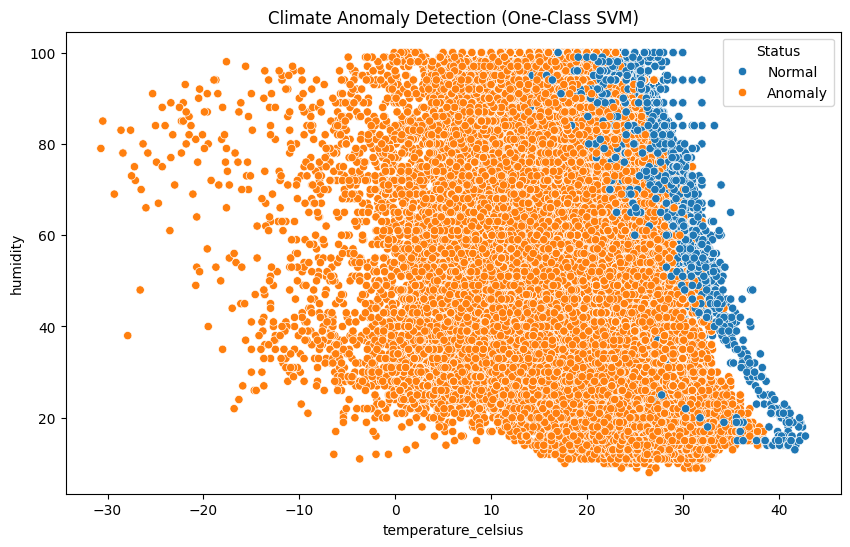

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='temperature_celsius',
    y='humidity',
    hue='Status'
)

plt.title('Climate Anomaly Detection (One-Class SVM)')
plt.show()

# SAVE ARTIFACTS

In [11]:
save_path = r"D:\ClimateGuardAI\backend\ml\artifacts"

os.makedirs(save_path, exist_ok=True)

# Save SVM model
with open(os.path.join(save_path, 'climate_anomaly_svm.pkl'), 'wb') as file:
    pickle.dump(svm_model, file)

# Save scaler
with open(os.path.join(save_path, 'climate_anomaly_scaler.pkl'), 'wb') as file:
    pickle.dump(scaler, file)

# Save best parameters
with open(os.path.join(save_path, 'climate_anomaly_svm_best_params.pkl'), 'wb') as file:
    pickle.dump(best_params, file)

print("\nSVM Model + parameters saved successfully.")


SVM Model + parameters saved successfully.


# TEST PREDICTION

In [12]:
new_data = pd.DataFrame([{
    'temperature_celsius': 45,
    'humidity': 20,
    'precip_mm': 0,
    'pressure_mb': 1002
}])

new_scaled = scaler.transform(new_data)
prediction = model.predict(new_scaled)

new_scaled = scaler.transform(new_data)
prediction = svm_model.predict(new_scaled)

print("\nPrediction Result:")

if prediction[0] == -1:
    print("Anomaly Detected")
else:
    print("Normal Condition")


Prediction Result:
Normal Condition
